In [1]:
import os as os
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import scipy
from scipy import stats
import sklearn as sk
from sklearn.metrics import mean_squared_error
warnings.filterwarnings('ignore')

In [1]:
import pandas as pd
import numpy as np

### Read CSV

In [2]:
os.listdir()

['.ipynb_checkpoints',
 'bigmart_1148_final_restored.csv',
 'bigmart_1148_restored.csv',
 'bigmart_1148_restored_perfect.csv',
 'bigmart_back_to_basics.csv',
 'bigmart_bagged_blended.csv',
 'bigmart_elite_bagged.csv',
 'bigmart_elite_final.csv',
 'bigmart_final_optimized.csv',
 'bigmart_final_submission.csv',
 'bigmart_restored_1148.csv',
 'bigmart_restored_1148_final.csv',
 'bigmart_submission_v2.csv',
 'bigmart_top500_final_push.csv',
 'bigmart_top500_restore.csv',
 'bigmart_top_rank_final.csv',
 'bigmart_xgb_mrp_bins.csv',
 'Big_Mart_sales_Prediction.ipynb',
 'catboost_info',
 'sample_submission_8RXa3c6.csv',
 'test_AbJTz2l.csv',
 'train_v9rqX0R.csv']

In [3]:
train = pd.read_csv('train_v9rqX0R.csv')

In [4]:
test = pd.read_csv('test_AbJTz2l.csv')

In [5]:
train['source'] = 'train'
test['source'] = 'test'

df = pd.concat([train,test], ignore_index = True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14204 entries, 0 to 14203
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            14204 non-null  object 
 1   Item_Weight                11765 non-null  float64
 2   Item_Fat_Content           14204 non-null  object 
 3   Item_Visibility            14204 non-null  float64
 4   Item_Type                  14204 non-null  object 
 5   Item_MRP                   14204 non-null  float64
 6   Outlet_Identifier          14204 non-null  object 
 7   Outlet_Establishment_Year  14204 non-null  int64  
 8   Outlet_Size                10188 non-null  object 
 9   Outlet_Location_Type       14204 non-null  object 
 10  Outlet_Type                14204 non-null  object 
 11  Item_Outlet_Sales          8523 non-null   float64
 12  source                     14204 non-null  object 
dtypes: float64(4), int64(1), object(8)
memory usag

In [7]:
df.dtypes

Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
source                        object
dtype: object

In [8]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                  2439
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4016
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
source                          0
dtype: int64

#### Filling item weight with Item Identifier mean

In [9]:
df['Item_Weight'] = df['Item_Weight'].fillna(df.groupby('Item_Identifier')['Item_Weight'].transform('mean'))

In [10]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                  4016
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
source                          0
dtype: int64

In [11]:
df[df['Outlet_Size'].isna()]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,train
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986,train
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350,train
25,NCD06,13.000,Low Fat,0.099887,Household,45.9060,OUT017,2007,NaN,Tier 2,Supermarket Type1,838.9080,train
28,FDE51,5.925,Regular,0.161467,Dairy,45.5086,OUT010,1998,NaN,Tier 3,Grocery Store,178.4344,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14191,FDC44,15.600,Low Fat,0.288892,Fruits and Vegetables,115.1518,OUT010,1998,NaN,Tier 3,Grocery Store,NaN,test
14193,FDO03,10.395,Regular,0.037092,Meat,229.4352,OUT017,2007,NaN,Tier 2,Supermarket Type1,NaN,test
14201,NCO17,10.000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,NaN,Tier 2,Supermarket Type1,NaN,test
14202,FDJ26,15.300,Regular,0.000000,Canned,214.6218,OUT017,2007,NaN,Tier 2,Supermarket Type1,NaN,test


In [12]:
df[['Outlet_Location_Type','Outlet_Size', 'Outlet_Type']].value_counts(dropna = False).sort_values(ascending = True)

Outlet_Location_Type  Outlet_Size  Outlet_Type      
Tier 1                Small        Grocery Store         880
Tier 3                NaN          Grocery Store         925
                      Medium       Supermarket Type2    1546
Tier 1                Medium       Supermarket Type1    1550
                      Small        Supermarket Type1    1550
Tier 2                Small        Supermarket Type1    1550
Tier 3                High         Supermarket Type1    1553
                      Medium       Supermarket Type3    1559
Tier 2                NaN          Supermarket Type1    3091
Name: count, dtype: int64

In [13]:
mode_outlet_size = df.pivot_table(values='Outlet_Size', columns='Outlet_Type', aggfunc=(lambda x: x.mode()[0]))
mode_outlet_size

Outlet_Type,Grocery Store,Supermarket Type1,Supermarket Type2,Supermarket Type3
Outlet_Size,Small,Small,Medium,Medium


In [14]:
missing_values = df['Outlet_Size'].isnull()
df[missing_values]

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source
3,FDX07,19.200,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800,train
8,FDH17,16.200,Regular,0.016687,Frozen Foods,96.9726,OUT045,2002,NaN,Tier 2,Supermarket Type1,1076.5986,train
9,FDU28,19.200,Regular,0.094450,Frozen Foods,187.8214,OUT017,2007,NaN,Tier 2,Supermarket Type1,4710.5350,train
25,NCD06,13.000,Low Fat,0.099887,Household,45.9060,OUT017,2007,NaN,Tier 2,Supermarket Type1,838.9080,train
28,FDE51,5.925,Regular,0.161467,Dairy,45.5086,OUT010,1998,NaN,Tier 3,Grocery Store,178.4344,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14191,FDC44,15.600,Low Fat,0.288892,Fruits and Vegetables,115.1518,OUT010,1998,NaN,Tier 3,Grocery Store,NaN,test
14193,FDO03,10.395,Regular,0.037092,Meat,229.4352,OUT017,2007,NaN,Tier 2,Supermarket Type1,NaN,test
14201,NCO17,10.000,Low Fat,0.073529,Health and Hygiene,118.7440,OUT045,2002,NaN,Tier 2,Supermarket Type1,NaN,test
14202,FDJ26,15.300,Regular,0.000000,Canned,214.6218,OUT017,2007,NaN,Tier 2,Supermarket Type1,NaN,test


In [15]:
df.loc[missing_values, 'Outlet_Size'] = df.loc[missing_values, 'Outlet_Type'].apply(lambda x: mode_outlet_size[x])

In [16]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
source                          0
dtype: int64

In [17]:
df.describe(include = 'all')

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source
count,14204,14204.000000,14204,14204.000000,14204,14204.000000,14204,14204.000000,14204,14204,14204,8523.000000,14204
unique,1559,NaN,5,NaN,16,NaN,10,NaN,3,3,4,NaN,2
top,FDU15,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,OUT027,NaN,Small,Tier 3,Supermarket Type1,NaN,train
freq,10,NaN,8485,NaN,2013,NaN,1559,NaN,7996,5583,9294,NaN,8523
mean,NaN,12.793380,NaN,0.065953,NaN,141.004977,NaN,1997.830681,NaN,NaN,NaN,2181.288914,NaN
std,NaN,4.651716,NaN,0.051459,NaN,62.086938,NaN,8.371664,NaN,NaN,NaN,1706.499616,NaN
min,NaN,4.555000,NaN,0.000000,NaN,31.290000,NaN,1985.000000,NaN,NaN,NaN,33.290000,NaN
25%,NaN,8.710000,NaN,0.027036,NaN,94.012000,NaN,1987.000000,NaN,NaN,NaN,834.247400,NaN
50%,NaN,12.600000,NaN,0.054021,NaN,142.247000,NaN,1999.000000,NaN,NaN,NaN,1794.331000,NaN
75%,NaN,16.750000,NaN,0.094037,NaN,185.855600,NaN,2004.000000,NaN,NaN,NaN,3101.296400,NaN


#### Inspecting zero Item Visibility

In [18]:
print((df['Item_Visibility'] == 0).sum())

879


In [19]:
df['Item_Visibility'] = df['Item_Visibility'].replace(0, np.nan)

In [20]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility               879
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
source                          0
dtype: int64

In [21]:
df['Item_Visibility'] = df['Item_Visibility'].fillna(df.groupby ('Item_Identifier')['Item_Visibility'].transform('mean'))

In [22]:
df.isna().sum()

Item_Identifier                 0
Item_Weight                     0
Item_Fat_Content                0
Item_Visibility                 0
Item_Type                       0
Item_MRP                        0
Outlet_Identifier               0
Outlet_Establishment_Year       0
Outlet_Size                     0
Outlet_Location_Type            0
Outlet_Type                     0
Item_Outlet_Sales            5681
source                          0
dtype: int64

In [23]:
df.describe(include = 'all')

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source
count,14204,14204.000000,14204,14204.000000,14204,14204.000000,14204,14204.000000,14204,14204,14204,8523.000000,14204
unique,1559,NaN,5,NaN,16,NaN,10,NaN,3,3,4,NaN,2
top,FDU15,NaN,Low Fat,NaN,Fruits and Vegetables,NaN,OUT027,NaN,Small,Tier 3,Supermarket Type1,NaN,train
freq,10,NaN,8485,NaN,2013,NaN,1559,NaN,7996,5583,9294,NaN,8523
mean,NaN,12.793380,NaN,0.070458,NaN,141.004977,NaN,1997.830681,NaN,NaN,NaN,2181.288914,NaN
std,NaN,4.651716,NaN,0.050086,NaN,62.086938,NaN,8.371664,NaN,NaN,NaN,1706.499616,NaN
min,NaN,4.555000,NaN,0.003575,NaN,31.290000,NaN,1985.000000,NaN,NaN,NaN,33.290000,NaN
25%,NaN,8.710000,NaN,0.031381,NaN,94.012000,NaN,1987.000000,NaN,NaN,NaN,834.247400,NaN
50%,NaN,12.600000,NaN,0.058064,NaN,142.247000,NaN,1999.000000,NaN,NaN,NaN,1794.331000,NaN
75%,NaN,16.750000,NaN,0.098042,NaN,185.855600,NaN,2004.000000,NaN,NaN,NaN,3101.296400,NaN


In [24]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    8485
Regular    4824
LF          522
reg         195
low fat     178
Name: count, dtype: int64

In [25]:
df['Item_Fat_Content'] = df['Item_Fat_Content'].replace({
    'LF':'Low Fat',
    'low fat':'Low Fat',
    'reg':'Regular'
}    
)

In [26]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat    9185
Regular    5019
Name: count, dtype: int64

### Checking outliers in numerical columns

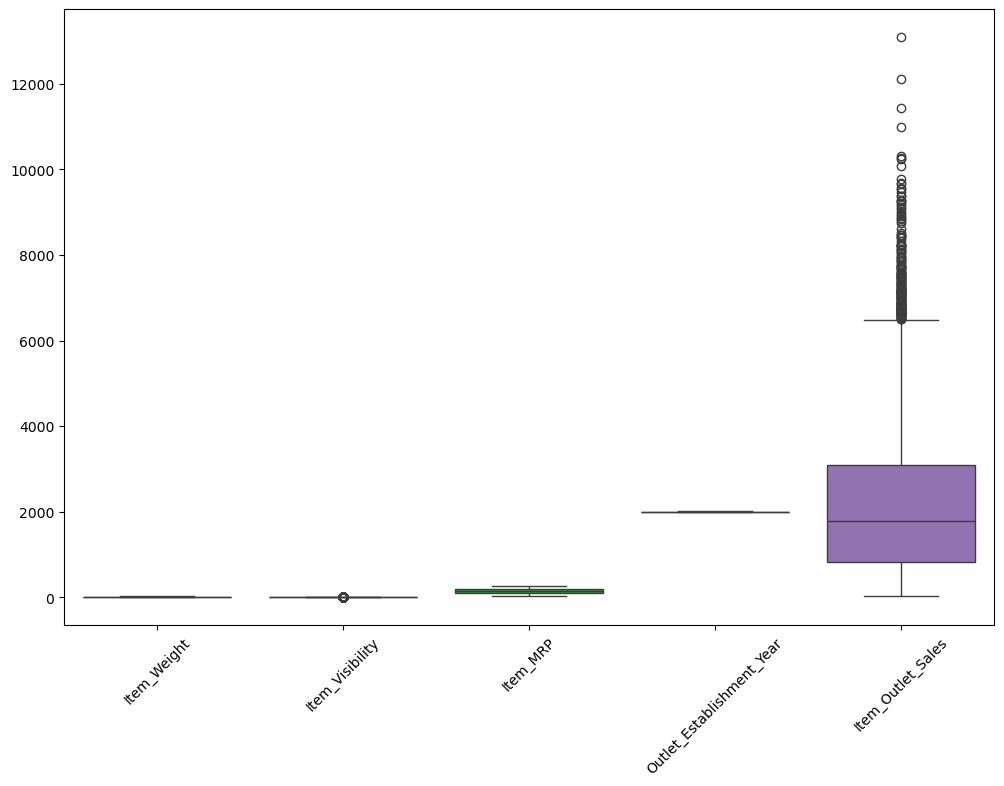

In [27]:
numerical_columns = df.select_dtypes(include=['number']).columns

plt.figure(figsize = (12,8))
sns.boxplot(data=df[numerical_columns])
plt.xticks(rotation = 45)
plt.show()

In [28]:
# Above - Maybe need to use log normalization for Item_outlet_sales

### Creating Item type categories based on Item identifier

In [29]:
df['Item_type_combined'] = df['Item_Identifier'].apply(lambda x: x[0:2])

In [30]:
df['Item_type_combined'].value_counts()

Item_type_combined
FD    10201
NC     2686
DR     1317
Name: count, dtype: int64

In [31]:
df['Item_type_combined'] = df['Item_type_combined'].replace({
    'FD':'Food',
    'NC':'Non-Consumable',
    'DR':'Drinks'
}    
)

In [32]:
df['Item_type_combined'].value_counts()

Item_type_combined
Food              10201
Non-Consumable     2686
Drinks             1317
Name: count, dtype: int64

In [33]:
df['Item_type_combined'].isna().sum()

0

#### Replacing Item Fat content for Non consumables

In [34]:
df.loc[df['Item_type_combined'] == 'Non-Consumable', 'Item_Fat_Content'] = 'Non-Edible'

In [35]:
df['Item_Fat_Content'].value_counts()

Item_Fat_Content
Low Fat       6499
Regular       5019
Non-Edible    2686
Name: count, dtype: int64

## Feature Engineering

#### Price Per weight units feature

In [36]:
df['Item_MRP_per_weight'] = df['Item_MRP']/df['Item_Weight']

In [37]:
df['Item_MRP_per_weight'].describe()

count    14204.000000
mean        12.801220
std          8.068422
min          1.665236
25%          6.829986
50%         10.982940
75%         16.341980
max         50.775731
Name: Item_MRP_per_weight, dtype: float64

In [38]:
df.select_dtypes(include = ['number']).corr()

,Item_Weight,Item_Visibility,Item_MRP,Outlet_Establishment_Year,Item_Outlet_Sales,Item_MRP_per_weight
Item_Weight,1.000000,-0.023856,0.035751,0.000247,0.013261,-0.606616
Item_Visibility,-0.023856,1.000000,-0.009052,-0.083799,-0.127014,0.000018
Item_MRP,0.035751,-0.009052,1.000000,0.000141,0.567574,0.681309
Outlet_Establishment_Year,0.000247,-0.083799,0.000141,1.000000,-0.049135,-0.000505
Item_Outlet_Sales,0.013261,-0.127014,0.567574,-0.049135,1.000000,0.383348
Item_MRP_per_weight,-0.606616,0.000018,0.681309,-0.000505,0.383348,1.000000


#### Creating feature of Outlet Establishment Age

In [39]:
df['Outlet_Years'] = 2013 - df['Outlet_Establishment_Year']

In [40]:
df.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].sum().sort_values(ascending = False)

Outlet_Establishment_Year
1985    3.633620e+06
2004    2.268123e+06
1999    2.183970e+06
2007    2.167465e+06
1987    2.142664e+06
1997    2.118395e+06
2002    2.036725e+06
2009    1.851823e+06
1998    1.883402e+05
Name: Item_Outlet_Sales, dtype: float64

#### Creating MRP Level Bins

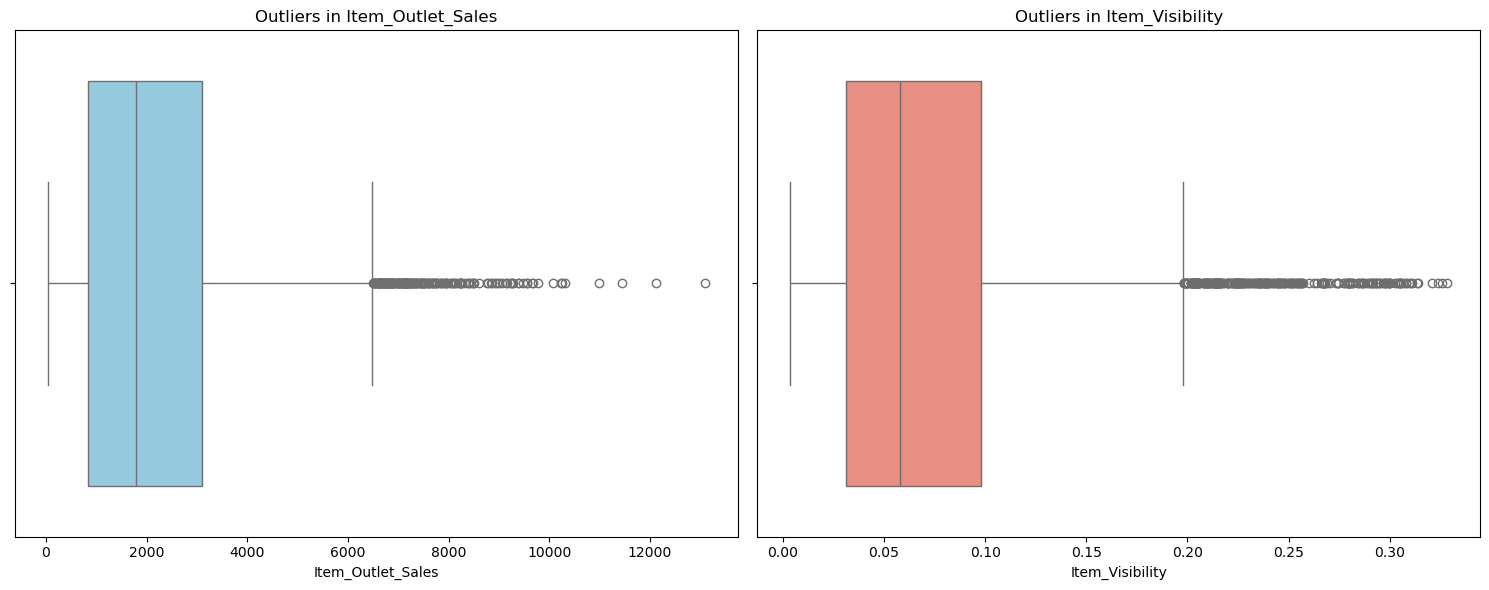

Sales Skewness: 1.18
Visibility Skewness: 1.23


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Item_Outlet_Sales (Target Variable)
sns.boxplot(x=df['Item_Outlet_Sales'], ax=axes[0], color='skyblue')
axes[0].set_title('Outliers in Item_Outlet_Sales')

# Plot 2: Item_Visibility (Feature)
sns.boxplot(x=df['Item_Visibility'], ax=axes[1], color='salmon')
axes[1].set_title('Outliers in Item_Visibility')

plt.tight_layout()
plt.show()

# Print skewness values (Values > 1 indicate high right-skew)
print(f"Sales Skewness: {df['Item_Outlet_Sales'].skew():.2f}")
print(f"Visibility Skewness: {df['Item_Visibility'].skew():.2f}")


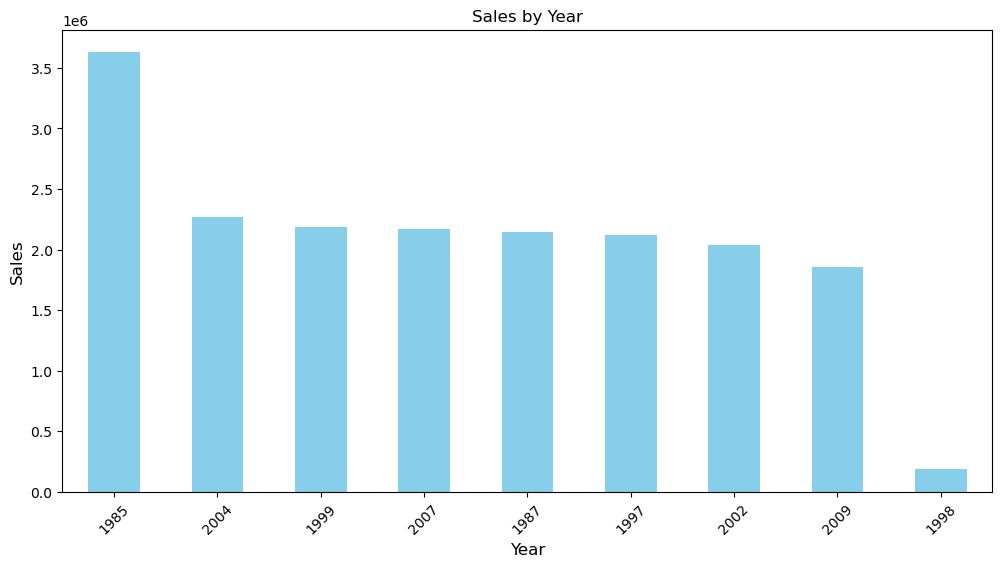

In [42]:
yearly_sales = df.groupby('Outlet_Establishment_Year')['Item_Outlet_Sales'].sum().sort_values(ascending=False)
yearly_sales

plt.figure(figsize = (12,6))
yearly_sales.plot(kind='bar', color = 'skyblue')

plt.title('Sales by Year')
plt.xlabel('Year', fontsize = 12)
plt.ylabel('Sales', fontsize = 12)
plt.xticks(rotation=45)
plt.show()

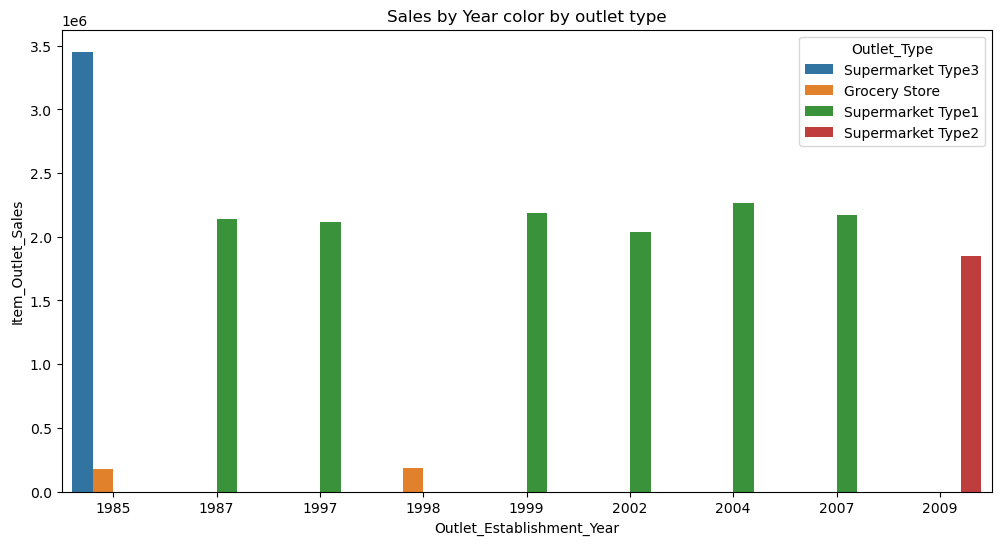

In [43]:
plt.figure(figsize = (12,6))
sns.barplot(x='Outlet_Establishment_Year', y='Item_Outlet_Sales',hue = 'Outlet_Type', data=df, estimator=sum, ci=None)
plt.title('Sales by Year color by outlet type')
plt.show()

#### Feature Engineering

In [48]:
df

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales,source,Item_type_combined,Item_MRP_per_weight,Outlet_Years
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380,train,Food,26.861204,14
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228,train,Drinks,8.153581,4
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700,train,Food,8.092457,14
3,FDX07,19.20,Regular,0.022930,Fruits and Vegetables,182.0950,OUT010,1998,Small,Tier 3,Grocery Store,732.3800,train,Food,9.484115,15
4,NCD19,8.93,Non-Edible,0.014670,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052,train,Non-Consumable,6.031512,26
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14199,FDB58,10.50,Regular,0.013496,Snack Foods,141.3154,OUT046,1997,Small,Tier 1,Supermarket Type1,NaN,test,Food,13.458610,16
14200,FDD47,7.60,Regular,0.142991,Starchy Foods,169.1448,OUT018,2009,Medium,Tier 3,Supermarket Type2,NaN,test,Food,22.255895,4
14201,NCO17,10.00,Non-Edible,0.073529,Health and Hygiene,118.7440,OUT045,2002,Small,Tier 2,Supermarket Type1,NaN,test,Non-Consumable,11.874400,11
14202,FDJ26,15.30,Regular,0.098200,Canned,214.6218,OUT017,2007,Small,Tier 2,Supermarket Type1,NaN,test,Food,14.027569,6


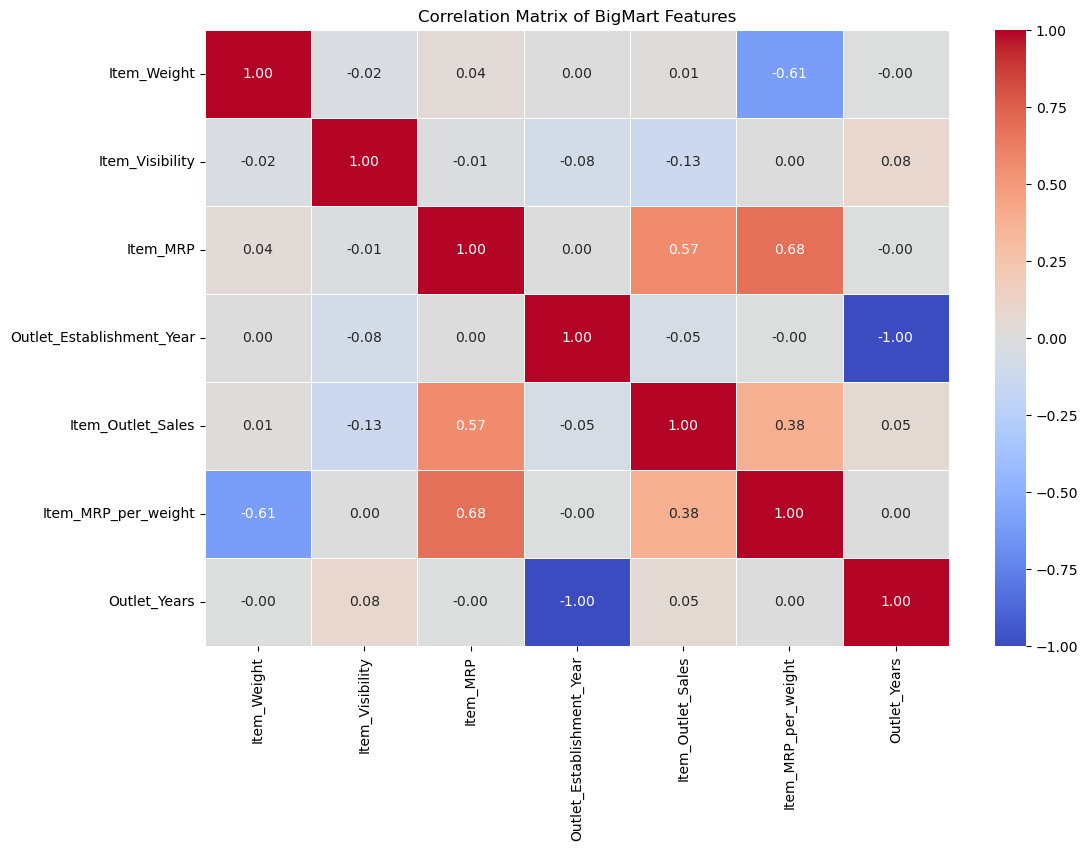

In [47]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Calculate correlation (only for numeric columns)
corr_matrix = df.select_dtypes('number').corr()

# 2. Plot the Heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix of BigMart Features')
plt.show()


### Encoding variables

In [51]:
# 1. Label Encode (Ordered)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Outlet_Size'] = le.fit_transform(df['Outlet_Size'])
df['Outlet_Location_Type'] = le.fit_transform(df['Outlet_Location_Type'])

# 2. One-Hot Encode (Unordered)
df = pd.get_dummies(df, columns=['Item_Fat_Content', 'Outlet_Type', 'Item_type_combined', 'Outlet_Identifier'])

# 3. Drop redundant columns
df.drop(columns=['Item_Type', 'Outlet_Establishment_Year'], inplace=True)


In [58]:
# 1. Define a function to categorize MRP based on the gaps in the distribution
def assign_mrp_bin(x):
    if x < 69:
        return 'Low'
    elif x < 136:
        return 'Medium'
    elif x < 203:
        return 'High'
    else:
        return 'Premium'

# 2. Apply the function and One-Hot Encode the new feature
df['MRP_Level'] = df['Item_MRP'].apply(assign_mrp_bin)
df = pd.get_dummies(df, columns=['MRP_Level'])

print("MRP Bins created and encoded!")


MRP Bins created and encoded!


In [53]:
# Separate back into train and test
train_final = df.loc[df['source'] == "train"]
test_final = df.loc[df['source'] == "test"]

# Remove the 'source' flag and the empty 'Item_Outlet_Sales' from the test set
train_final.drop(columns=['source'], inplace=True)
test_final.drop(columns=['source', 'Item_Outlet_Sales'], inplace=True)


In [54]:
# Create a copy so we don't lose our original IDs
df_model = df.copy()

In [56]:
from sklearn.ensemble import RandomForestRegressor

# 1. Save the IDs before dropping everything else (we need these for the CSV)
# We use .values to get the raw data so indexing doesn't cause issues
test_ids = test_final[['Item_Identifier', 'Outlet_Identifier_OUT010', 'Outlet_Identifier_OUT013', 
                       'Outlet_Identifier_OUT017', 'Outlet_Identifier_OUT018', 'Outlet_Identifier_OUT019',
                       'Outlet_Identifier_OUT027', 'Outlet_Identifier_OUT035', 'Outlet_Identifier_OUT045',
                       'Outlet_Identifier_OUT046', 'Outlet_Identifier_OUT049']] 
                       # Note: If your columns have different names, just use the original 'test' dataframe for IDs.

# 2. Prepare X_train (Features only)
# 'Outlet_Identifier' is already gone from encoding, so we only drop Sales and Item_Identifier
X_train = train_final.drop(columns=['Item_Outlet_Sales', 'Item_Identifier'], errors='ignore')
y_train = train_final['Item_Outlet_Sales']

# 3. Prepare X_test (Must match X_train exactly)
X_test = test_final.drop(columns=['Item_Identifier'], errors='ignore')

# 4. Initialize and Train
rf_model = RandomForestRegressor(n_estimators=400, max_depth=6, min_samples_leaf=100, n_jobs=-1, random_state=42)
rf_model.fit(X_train, y_train)

# 5. Predict
test_predictions = rf_model.predict(X_test)

# 6. Create Submission using the ORIGINAL test data for IDs (safest way)
# Assuming 'test' is your original dataframe before encoding
submission = pd.DataFrame({
    'Item_Identifier': test['Item_Identifier'],
    'Outlet_Identifier': test['Outlet_Identifier'],
    'Item_Outlet_Sales': test_predictions
})

submission.to_csv('bigmart_submission_v2.csv', index=False)
print("Submission file is ready!")


Submission file is ready!


In [59]:
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score

# 1. Re-split your data (X_train, y_train, X_test) 
# Ensure 'source' and 'Item_Identifier' are dropped as before
X_train = train_final.drop(columns=['Item_Outlet_Sales', 'Item_Identifier', 'source'], errors='ignore')
y_train = train_final['Item_Outlet_Sales']
X_test = test_final.drop(columns=['Item_Identifier', 'source'], errors='ignore')

# 2. Initialize XGBoost with "Competition-Ready" hyperparameters
xgb_model = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.01, # Slow learning rate is more precise
    max_depth=5,        # Prevents overfitting
    subsample=0.8,      # Uses 80% of data per tree to stay robust
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42
)

# 3. Validation: Check the score before submitting
# This simulates the leaderboard score on your own computer
scores = cross_val_score(xgb_model, X_train, y_train, scoring='neg_root_mean_squared_error', cv=5)
print(f"Estimated Leaderboard RMSE: {-scores.mean():.2f}")

# 4. Final Fit and Predict
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_test)


Estimated Leaderboard RMSE: 1099.75


In [60]:
# Ensure no negative sales predictions
xgb_preds = [max(0, x) for x in xgb_preds]

# Create the new submission file
submission_v3 = pd.DataFrame({
    'Item_Identifier': test['Item_Identifier'],
    'Outlet_Identifier': test['Outlet_Identifier'],
    'Item_Outlet_Sales': xgb_preds
})

submission_v3.to_csv('bigmart_xgb_mrp_bins.csv', index=False)


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 1. Initialize and Train
model = LinearRegression()
model.fit(X_train, y_train)

# 2. Make Predictions
predictions = model.predict(X_test)

# 3. Calculate Error
rmse = np.sqrt(mean_squared_error(y_test, predictions))
print(f"Baseline RMSE: {rmse:.2f}")


In [ ]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor

kf = KFold(n_splits=5, shuffle=True, random_state=42)
final_test_preds = np.zeros(len(X_test))

for train_idx, val_idx in kf.split(X):
    xt, xv = X.iloc[train_idx], X.iloc[val_idx]
    yt, yv = y.iloc[train_idx], y.iloc[val_idx]
    
    # Conservative XGBoost to prevent Private LB Shakedown
    model = XGBRegressor(n_estimators=500, learning_rate=0.02, max_depth=3, subsample=0.8, colsample_bytree=0.8, random_state=42)
    model.fit(xt, yt)
    
    # Average the predictions
    final_test_preds += model.predict(X_test) / 5

# Create Submission
submission = pd.DataFrame({
    'Item_Identifier': test_final['Item_Identifier'],
    'Outlet_Identifier': test['Outlet_Identifier'], # Use original for ID
    'Item_Outlet_Sales': [max(0, p) for p in final_test_preds]
})
submission.to_csv('bigmart_elite_pruned.csv', index=False)


In [ ]:
# --- STEP 4: THE ULTIMATE SUBMISSION FIX ---

# 1. Load a fresh copy of the test file to get clean IDs
# This avoids all index mismatch issues from previous steps
test_original = pd.read_csv('test_AbJTz2l.csv') 

# 2. Verify lengths (both should be 5681)
print(f"Predictions length: {len(final_test_preds)}")
print(f"Test IDs length: {len(test_original)}")

# 3. Create the final submission dataframe
submission = pd.DataFrame({
    'Item_Identifier': test_original['Item_Identifier'],
    'Outlet_Identifier': test_original['Outlet_Identifier'],
    'Item_Outlet_Sales': [max(0, p) for p in final_test_preds]
})

# 4. Save to CSV
submission.to_csv('bigmart_elite_final.csv', index=False)
print("--- SUCCESS: Final optimized submission file created! ---")


In [ ]:
import pandas as pd
import numpy as np

# --- 1. Target Mean Encoding (The Ranking Secret) ---
# We calculate the mean sales for each Item_Type from the training data only
item_type_means = train_final.groupby('Item_Type')['Item_Outlet_Sales'].mean()
df['Item_Type_Target_Enc'] = df['Item_Type'].map(item_type_means)

# --- 2. Final Feature Selection ---
# Dropping non-numeric IDs and redundant original columns
drop_list = ['Item_Identifier', 'Outlet_Identifier', 'Item_Type', 'Outlet_Establishment_Year', 'source']
X_all = df.drop(columns=drop_list + ['Item_Outlet_Sales'], errors='ignore')
y_all = df['Item_Outlet_Sales']

# --- 3. Split back using your Checkpoint ---
X_train_final = X_all.loc[df['source'] == 'train'].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
X_test_final = X_all.loc[df['source'] == 'test'].apply(pd.to_numeric, errors='coerce').fillna(0).astype(float)
y_train_final = y_all.loc[df['source'] == 'train']

print(f"Checkpoint Ready. Feature Matrix Shape: {X_train_final.shape}")


In [ ]:
from sklearn.model_selection import KFold
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error

kf = KFold(n_splits=5, shuffle=True, random_state=42)
test_preds_total = np.zeros(len(X_test_final))
cv_rmse = []

for i, (train_idx, val_idx) in enumerate(kf.split(X_train_final)):
    # Split for this fold
    xt, xv = X_train_final.iloc[train_idx], X_train_final.iloc[val_idx]
    yt, yv = y_train_final.iloc[train_idx], y_train_final.iloc[val_idx]
    
    # Model tuned for stability on Private LB
    m = XGBRegressor(n_estimators=500, learning_rate=0.02, max_depth=3, subsample=0.8, colsample_bytree=0.8)
    m.fit(xt, yt)
    
    # Validation check for this fold
    preds_v = [max(0, p) for p in m.predict(xv)]
    cv_rmse.append(np.sqrt(mean_squared_error(yv, preds_v)))
    
    # Accumulate predictions for the final average
    test_preds_total += m.predict(X_test_final)

print(f"Bagged XGBoost Stable RMSE: {np.mean(cv_rmse):.2f}")
final_bagged_xgb = [max(0, p) for p in (test_preds_total / 5)]


In [ ]:
# pip install catboost
from catboost import CatBoostRegressor

cb_model = CatBoostRegressor(iterations=1000, learning_rate=0.01, depth=5, verbose=0, random_seed=42)
cb_model.fit(X_train_final, y_train_final)

final_preds_cat = [max(0, p) for p in cb_model.predict(X_test_final)]
print("CatBoost model trained successfully.")


In [ ]:
# Blending two different model architectures for maximum stability
final_blended_preds = (0.7 * np.array(final_bagged_xgb)) + (0.3 * np.array(final_preds_cat))

submission_v7 = pd.DataFrame({
    'Item_Identifier': test['Item_Identifier'],
    'Outlet_Identifier': test['Outlet_Identifier'],
    'Item_Outlet_Sales': final_blended_preds
})

submission_v7.to_csv('bigmart_bagged_blended.csv', index=False)
print("Ensemble submission 'bigmart_bagged_blended.csv' generated!")
